In [3]:
print("ok")

ok


In [1]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [2]:
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [3]:
if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY is missing from .env")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [5]:
chat_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
# chat_llm = ChatGoogleGenerativeAI(model = "gemini-3-flash-preview")

In [6]:
chat_llm.invoke("Hello, how are you?").content

"Hello! I am doing well, thank you for asking. As an AI, I don't experience feelings in the same way humans do, but I am functioning optimally and ready to assist you.\n\nHow are you doing today? Is there anything I can help you with?"

In [7]:
from typing_extensions import TypedDict, Annotated
import operator

In [8]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [9]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]

In [10]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])
    return{
        "messages":[response]
    }

In [11]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    # Handle both string and list content
    if isinstance(text, list):
        text = str(text)
    token_number = len(text.split())
    summary = f"Total tokens in generates answer: {token_number}"
    return{
        "messages":[AIMessage(content=summary)]
    }

In [12]:
from langgraph.graph import StateGraph

In [13]:
builder = StateGraph(GraphState)

In [14]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [15]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call","token_counter")
builder.set_finish_point("token_counter")

In [16]:
app = builder.compile()

In [17]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [18]:
from IPython.display import Image, display

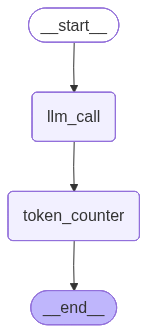

In [19]:
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
result = app.invoke({
    "messages":[HumanMessage(content="Hi,Tell me what are AI agents.")]
})

In [21]:
result

{'messages': [HumanMessage(content='Hi,Tell me what are AI agents.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='AI agents are a fascinating and rapidly evolving concept in artificial intelligence. At their core, they are **entities that can perceive their environment, make decisions, and take actions to achieve specific goals.** Think of them as intelligent software programs or even physical robots that can operate autonomously to some degree.\n\nHere\'s a breakdown of what makes an AI agent:\n\n**Key Characteristics of AI Agents:**\n\n*   **Perception:** Agents need to sense or observe their environment. This can be through:\n    *   **Sensors:** For physical agents (robots), this could be cameras, microphones, touch sensors, GPS, etc.\n    *   **Data Streams:** For software agents, this could be data from websites, databases, APIs, user input, sensor readings from IoT devices, etc.\n*   **Decision-Making (Reasoning/Intelligence):** Based on their perceptions an

In [22]:
for m in result["messages"]:
    print(type(m).__name__,":",m.content)

HumanMessage : Hi,Tell me what are AI agents.
AIMessage : AI agents are a fascinating and rapidly evolving concept in artificial intelligence. At their core, they are **entities that can perceive their environment, make decisions, and take actions to achieve specific goals.** Think of them as intelligent software programs or even physical robots that can operate autonomously to some degree.

Here's a breakdown of what makes an AI agent:

**Key Characteristics of AI Agents:**

*   **Perception:** Agents need to sense or observe their environment. This can be through:
    *   **Sensors:** For physical agents (robots), this could be cameras, microphones, touch sensors, GPS, etc.
    *   **Data Streams:** For software agents, this could be data from websites, databases, APIs, user input, sensor readings from IoT devices, etc.
*   **Decision-Making (Reasoning/Intelligence):** Based on their perceptions and their internal goals, agents must be able to decide what to do next. This involves:
 

In [23]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [24]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=300)

In [25]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [26]:
wiki_tool.run({"query":"What are AI agents?"})

'Page: AI agent\nSummary: In the context of generative artificial intelligence, AI agents (also referred to as compound AI systems or agentic AI) are a class of intelligent agents distinguished by their ability to operate autonomously in complex environments. Agentic AI tools prioritize decision-makin'

'Page: AI agent\nSummary: In the context of generative artificial intelligence, AI agents (also referred to as compound AI systems or agentic AI) are a class of intelligent agents distinguished by their ability to operate autonomously in complex environments. Agentic AI tools prioritize decision-makin'

In [27]:
import os
from langchain_community.tools import TavilySearchResults
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [28]:
print(TAVILY_API_KEY)

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


In [29]:
tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

C:\Users\Sahil\AppData\Local\Temp\ipykernel_22964\709498164.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)


In [30]:
tool.invoke({"query":"What is the current AQI index in Delhi"})

[{'title': 'New Delhi Air Quality Index (AQI) | Air Pollution',
  'url': 'https://www.aqi.in/us/dashboard/india/delhi/new-delhi',
  'content': 'Your area’s real-time data with detailed parameters.\n\nPersonalized health advice as per current AQI.\n\nPersonalized health advice as per current AQI.\n\nAnalytical data to identify trends and conditions.\n\nAnalytical data to identify trends and conditions.\n\nConnect and control your air quality devices.\n\nConnect and control your air quality devices.\n\n## Air Quality FAQs at New Delhi\n\nAir Quality FAQs\n\nat New Delhi\n\nFrequently Asked Questions About Air Quality\n\nWhat is the current AQI (US) level in New Delhi?\n\nThe current real-time AQI (US) level in New Delhi is 118 (Poor). This was last updated 2026-02-25 18:01:00 (Local Time).\n\nWhen was the best AQI (US) level in New Delhi in the last 24 hours?\n\nThe best AQI (US) level was 108 (Poor) at 4:31 PM (Local Time) during the last 24 hours. [...] When was the worst AQI (US) leve

In [31]:
from langchain_community.tools import DuckDuckGoSearchRun
search = DuckDuckGoSearchRun()

In [32]:
search.invoke("What is current temperature in Manali?")

Impersonate 'safari_16.5' does not exist, using 'random'


'1 day ago - Current Manali weather condition is Moderate or heavy snow showers with real-time temperature (-1°C ), humidity 56%, wind 7.9km/h, pressure (1016mb), UV (2.9), visibility (7km) in Himachal Pradesh. 2 days ago - Manali weather today shows a temperature of -1°C with Sunny conditions. The current weather in Manali feels like -1°C , with humidity at 42%, wind blowing at 3.6 km/h, and a UV Index of 8.5. Visibility stands at 10 km. 1 week ago - Current Manali weather condition is Partly cloudy with real-time temperature ( 31°C ), humidity 63%, wind 17.6km/h, pressure (1013mb), UV (9.8), visibility (6km) in Chennai, Tamil Nadu. 14 January 2026 - Current Mall Road weather condition is Clear with real-time temperature (-10°C ), humidity 37%, wind 18.4km/h, pressure (1027mb), UV (0), visibility (10km) in Manali, Himachal Pradesh. 18 December 2025 - If you are hoping to see snowfall, ... The sky is mostly cloudy, the wind is soft but cold, and the temperature stays between 10–13°C th

In [33]:
from langchain_community.tools import YouTubeSearchTool
tool = YouTubeSearchTool()

In [34]:
print(tool.name)
print(tool.description)

youtube_search
search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional


In [35]:
tool.run("Mr Beast")

"['https://www.youtube.com/watch?v=5OLs1GWB4OA&pp=ygUITXIgQmVhc3Q%3D', 'https://www.youtube.com/watch?v=Xj0Jtjg3lHQ&pp=ygUITXIgQmVhc3Q%3D']"

In [36]:
from langchain.tools import tool

In [37]:
@tool
def divide(a:int,b:int) -> int:
    """Divide the two numbers"""
    try:
        return a/b
    except Exception as e:
        return "Denominator should not be zero"

In [38]:
print(divide.invoke({"a":15,"b":20}))
print(divide.invoke({"a":15,"b":0}))

0.75
Denominator should not be zero


In [39]:
print(divide.name)
print(divide.description)
print(divide.args)

divide
Divide the two numbers
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [40]:
import yfinance as yf

In [44]:
from pandas import Period


@tool
def get_stock_price(ticker:str) ->str:
    """this is the tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        #Get the last 1day historical data
        data = stock.history(period = "1d")

        if data.empty:
            return f"No data found "
        
        latest_close = data["Close"].iloc[-1]

        return f"Last closing price of {ticker.upper()} was {latest_close:.2f}."
    except Exception as e:
            return f"Error: {e}"    